[Epoch 0/1] Batch 0: Loss_C = 0.3116, Loss_G = -0.1656, Loss_contrast = 4.8967
[Epoch 0/1] Batch 50: Loss_C = -1.0776, Loss_G = 0.1259, Loss_contrast = 4.8480
[Epoch 0/1] Batch 100: Loss_C = -0.6874, Loss_G = -0.6323, Loss_contrast = 4.8424
[Epoch 0/1] Batch 150: Loss_C = -0.6721, Loss_G = -1.1839, Loss_contrast = 4.8424
[Epoch 0/1] 生成樣本統計: Mean = 0.0007, Std = 0.5731
[RLHF Epoch 0/1] Loss_RL = 0.9824, Gen_RL_Loss = -0.0770


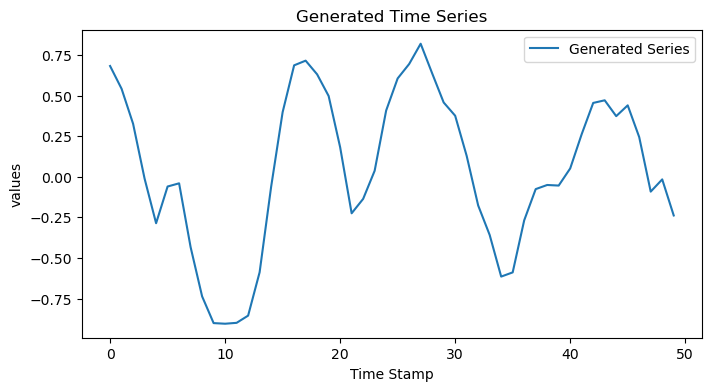

生成的時間序列形狀: torch.Size([1, 1, 50])
對應的 latent 表示: [[-9.82214138e-02  3.38967294e-01 -1.83167443e-01  5.46174087e-02
  -3.68094623e-01 -2.01555863e-01  1.94554031e-01 -1.33587748e-01
  -2.55319536e-01  1.79986656e-01  2.85257131e-01  1.31325155e-01
  -1.20332487e-01 -7.77091458e-02  2.24544525e-01 -6.39043329e-03
   2.98773527e-01 -1.79160103e-01  2.63236940e-01  2.29885757e-01
  -3.25164169e-01 -1.22251615e-01  9.62000191e-02 -8.77016783e-02
  -1.37093171e-01 -2.35948320e-02  8.23952109e-02  4.33371007e-01
   2.38396928e-01  9.69023481e-02  1.75142318e-01  2.06990480e-01
  -1.21995471e-01 -1.48904860e-01 -1.17933109e-01  3.51217508e-01
   7.20028132e-02  3.23843032e-01  1.71994641e-01  1.59076780e-01
   4.97390032e-02  1.92906395e-01 -1.72198698e-01 -1.66939929e-01
   3.58140796e-01  1.51417166e-01 -1.32005870e-01 -2.61771351e-01
  -3.42967473e-02  2.18031511e-01 -1.29779264e-01 -1.62131861e-01
   2.59375513e-01 -1.61744222e-01 -1.47102594e-01 -1.17472373e-04
   3.07522476e-01 -1.383044

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

#########################################
# 超參數設定
#########################################
latent_dim = 100         # 隱向量維度
seq_length = 50          # 時間序列長度
feature_dim = 1          # 單變量時間序列
batch_size = 64
critic_iterations = 5    # 每次訓練中 Critic 的更新次數
lambda_gp = 10           # 梯度懲罰係數
num_epochs = 1         # WGAN 與對比學習訓練的 epoch 數 (200)
rlhf_epochs = 1         # RLHF 微調的 epoch 數 (20)
margin = 1.0             # RLHF Ranking Loss 的 margin
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#########################################
# 模擬數據介面：產生模擬的時間序列數據
#########################################
class SimulatedTimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, num_samples, seq_length, feature_dim):
        super(SimulatedTimeSeriesDataset, self).__init__()
        self.num_samples = num_samples
        self.seq_length = seq_length
        self.feature_dim = feature_dim
        
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        # 以正弦波加隨機噪聲模擬時間序列
        t = torch.linspace(0, 2 * 3.14159, self.seq_length)
        freq = torch.rand(1) * 3 + 1         # 頻率介於 [1,4]
        amplitude = torch.rand(1) * 0.5 + 0.5  # 振幅介於 [0.5,1]
        phase = torch.rand(1) * 2 * 3.14159   # 隨機相位
        series = amplitude * torch.sin(freq * t + phase)
        series = series.unsqueeze(0)  # shape: (1, seq_length)
        if self.feature_dim > 1:
            series = series.repeat(self.feature_dim, 1)
        return series

num_samples = 10000
simulated_dataset = SimulatedTimeSeriesDataset(num_samples, seq_length, feature_dim)
real_data_loader = torch.utils.data.DataLoader(simulated_dataset, batch_size=batch_size, shuffle=True)

#########################################
# 定義 Generator：產生時間序列資料
# 修正生成輸出長度以適應非 4 整除的 seq_length
#########################################
class Generator(nn.Module):
    def __init__(self, latent_dim, seq_length, feature_dim):
        super(Generator, self).__init__()
        self.latent_dim = latent_dim
        self.seq_length = seq_length
        self.feature_dim = feature_dim
        # 利用 ceiling division 決定隱藏層長度
        self.hidden_length = (seq_length + 3) // 4  
        self.fc = nn.Linear(latent_dim, 128 * self.hidden_length)
        self.conv_blocks = nn.Sequential(
            nn.BatchNorm1d(128),
            nn.Upsample(scale_factor=2),
            nn.Conv1d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),  # 移除 inplace
            nn.Upsample(scale_factor=2),
            nn.Conv1d(64, feature_dim, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )
        
    def forward(self, z):
        out = self.fc(z)
        out = out.view(-1, 128, self.hidden_length)
        out = self.conv_blocks(out)
        # 使用 interpolate 調整輸出精確為 seq_length
        out = F.interpolate(out, size=self.seq_length, mode='linear', align_corners=False)
        return out

#########################################
# 定義 Critic：評估真實性 (動態計算 fc 輸入尺寸)
#########################################
class Critic(nn.Module):
    def __init__(self, seq_length, feature_dim):
        super(Critic, self).__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv1d(feature_dim, 64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),  # 移除 inplace
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),  # 移除 inplace
        )
        # 動態計算 conv 層輸出扁平化後的尺寸
        with torch.no_grad():
            dummy = torch.zeros(1, feature_dim, seq_length)
            dummy_out = self.conv_blocks(dummy)
            fc_input_dim = dummy_out.view(1, -1).size(1)
        self.fc = nn.Linear(fc_input_dim, 1)
    
    def forward(self, x):
        out = self.conv_blocks(x)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

#########################################
# 定義 Encoder：將時間序列編碼到 latent space (動態計算 fc 輸入尺寸)
#########################################
class Encoder(nn.Module):
    def __init__(self, seq_length, feature_dim, latent_dim):
        super(Encoder, self).__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv1d(feature_dim, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),  # 移除 inplace
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),  # 移除 inplace
        )
        with torch.no_grad():
            dummy = torch.zeros(1, feature_dim, seq_length)
            dummy_out = self.conv_blocks(dummy)
            fc_input_dim = dummy_out.view(1, -1).size(1)
        self.fc = nn.Linear(fc_input_dim, latent_dim)
    
    def forward(self, x):
        out = self.conv_blocks(x)
        out = out.view(out.size(0), -1)
        latent = self.fc(out)
        return latent

#########################################
# 定義 RewardModel：預測生成結果的 reward (動態計算 fc 輸入尺寸)
#########################################
class RewardModel(nn.Module):
    def __init__(self, seq_length, feature_dim):
        super(RewardModel, self).__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv1d(feature_dim, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),  # 移除 inplace
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),  # 移除 inplace
        )
        with torch.no_grad():
            dummy = torch.zeros(1, feature_dim, seq_length)
            dummy_out = self.conv_blocks(dummy)
            fc_input_dim = dummy_out.view(1, -1).size(1)
        self.fc = nn.Linear(fc_input_dim, 1)
    
    def forward(self, x):
        out = self.conv_blocks(x)
        out = out.view(out.size(0), -1)
        reward = self.fc(out)
        return reward

#########################################
# 定義對比損失函數：NT-Xent Loss 實現
#########################################
def contrastive_loss(z_i, z_j, temperature=0.5):
    # 正規化嵌入向量
    z_i = F.normalize(z_i, dim=1)
    z_j = F.normalize(z_j, dim=1)
    batch_size = z_i.shape[0]
    representations = torch.cat([z_i, z_j], dim=0)  # (2N, D)
    similarity_matrix = torch.matmul(representations, representations.T)
    
    # 建立正負例 label，確保在同一 device 上
    labels = torch.cat([torch.arange(batch_size, device=device) for _ in range(2)], dim=0)
    labels = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()
    
    # 排除對角線項
    mask = torch.eye(labels.shape[0], dtype=torch.bool, device=device)
    labels = labels[~mask].view(labels.shape[0], -1)
    similarity_matrix = similarity_matrix[~mask].view(similarity_matrix.shape[0], -1)
    
    # 提取正例與負例：正例放在 logits 的第一位
    positives = similarity_matrix[labels.bool()].view(labels.shape[0], -1)
    negatives = similarity_matrix[~labels.bool()].view(similarity_matrix.shape[0], -1)
    
    logits = torch.cat([positives, negatives], dim=1)
    target = torch.zeros(logits.shape[0], dtype=torch.long, device=device)
    
    logits = logits / temperature
    loss = F.cross_entropy(logits, target)
    return loss

#########################################
# 梯度懲罰計算（WGAN-GP 所需）
#########################################
def compute_gradient_penalty(critic, real_samples, fake_samples):
    alpha = torch.rand(real_samples.size(0), 1, 1, device=device)
    interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)
    d_interpolates = critic(interpolates)
    fake = torch.ones(real_samples.size(0), 1, device=device)
    gradients = autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

#########################################
# 初始化模型與優化器
#########################################
generator = Generator(latent_dim, seq_length, feature_dim).to(device)
critic = Critic(seq_length, feature_dim).to(device)
encoder = Encoder(seq_length, feature_dim, latent_dim).to(device)
reward_model = RewardModel(seq_length, feature_dim).to(device)

optimizer_G = optim.Adam(generator.parameters(), lr=1e-4, betas=(0.5, 0.9))
optimizer_C = optim.Adam(critic.parameters(), lr=1e-4, betas=(0.5, 0.9))
optimizer_E = optim.Adam(encoder.parameters(), lr=1e-4, betas=(0.5, 0.9))
optimizer_R = optim.Adam(reward_model.parameters(), lr=1e-4, betas=(0.5, 0.9))

#########################################
# WGAN 與 TS-TCC 對比學習訓練流程
#########################################
for epoch in range(num_epochs):
    for i, real_series in enumerate(real_data_loader):
        real_series = real_series.to(device)  # (B, feature_dim, seq_length)
        
        ## 1. Critic 訓練 (多次更新)
        for _ in range(critic_iterations):
            z = torch.randn(real_series.size(0), latent_dim, device=device)
            fake_series = generator(z)
            
            critic_real = critic(real_series)
            critic_fake = critic(fake_series)
            
            gp = compute_gradient_penalty(critic, real_series, fake_series)
            loss_C = -torch.mean(critic_real) + torch.mean(critic_fake) + lambda_gp * gp
            
            optimizer_C.zero_grad()
            loss_C.backward()
            optimizer_C.step()
        
        ## 2. 生成器與 Encoder 聯合訓練
        z = torch.randn(real_series.size(0), latent_dim, device=device)
        fake_series = generator(z)
        critic_fake = critic(fake_series)
        loss_G = -torch.mean(critic_fake)
        
        # 使用輕微擾動後的數據進行對比學習
        aug_real = real_series + 0.01 * torch.randn_like(real_series)
        aug_fake = fake_series + 0.01 * torch.randn_like(fake_series)
        latent_real = encoder(aug_real)
        latent_fake = encoder(aug_fake)
        loss_contrast = contrastive_loss(latent_real, latent_fake)
        
        total_loss = loss_G + loss_contrast
        
        optimizer_G.zero_grad()
        optimizer_E.zero_grad()
        total_loss.backward()
        optimizer_G.step()
        optimizer_E.step()
        
        if i % 50 == 0:
            print(f"[Epoch {epoch}/{num_epochs}] Batch {i}: Loss_C = {loss_C.item():.4f}, Loss_G = {loss_G.item():.4f}, Loss_contrast = {loss_contrast.item():.4f}")
    
    # 每個 epoch 結束時，利用生成器生成一個樣本，並檢查統計特性
    with torch.no_grad():
        z_sample = torch.randn(1, latent_dim, device=device)
        gen_sample = generator(z_sample)
        sample_mean = gen_sample.mean().item()
        sample_std = gen_sample.std().item()
        print(f"[Epoch {epoch}/{num_epochs}] 生成樣本統計: Mean = {sample_mean:.4f}, Std = {sample_std:.4f}")

#########################################
# RLHF 微調流程 —— 分別重新計算 forward 傳播以避免重複使用同一計算圖
#########################################
for epoch in range(rlhf_epochs):
    # 產生兩組生成樣本 (第一次 forward，用於 reward_model 更新)
    z1 = torch.randn(batch_size, latent_dim, device=device)
    z2 = torch.randn(batch_size, latent_dim, device=device)
    gen_seq1 = generator(z1)
    gen_seq2 = generator(z2)
    
    # 向量化模擬人類偏好：以生成序列的平均值較高者為偏好
    mean1 = gen_seq1.view(batch_size, -1).mean(dim=1, keepdim=True)
    mean2 = gen_seq2.view(batch_size, -1).mean(dim=1, keepdim=True)
    preferred = (mean1 >= mean2).float()  # (B, 1)
    
    # 使用 RewardModel 為生成結果打分 (第一次 forward)
    reward1 = reward_model(gen_seq1)
    reward2 = reward_model(gen_seq2)
    
    # Ranking Loss 向量化計算
    loss_rl = torch.where(preferred == 1,
                            F.relu(margin - (reward1 - reward2)),
                            F.relu(margin - (reward2 - reward1))).mean()
    
    optimizer_R.zero_grad()
    loss_rl.backward()
    optimizer_R.step()
    
    # 重新計算 generator 輸出 (第二次 forward，用於生成器更新)
    gen_seq1_for_gen = generator(z1)
    gen_seq2_for_gen = generator(z2)
    reward1_for_gen = reward_model(gen_seq1_for_gen)
    reward2_for_gen = reward_model(gen_seq2_for_gen)
    gen_loss_rl = - (preferred * reward1_for_gen + (1 - preferred) * reward2_for_gen).mean()
    
    optimizer_G.zero_grad()
    gen_loss_rl.backward()
    optimizer_G.step()
    
    print(f"[RLHF Epoch {epoch}/{rlhf_epochs}] Loss_RL = {loss_rl.item():.4f}, Gen_RL_Loss = {gen_loss_rl.item():.4f}")

#########################################
# Demo：呼叫模型並展示生成效果
#########################################
def demo_model(generator, encoder, latent_dim, device):
    """
    呼叫訓練好的 generator 與 encoder 模型，
    生成一筆時間序列數據並利用 matplotlib 畫出曲線，
    同時輸出 latent 表示。
    """
    with torch.no_grad():
        # 產生隨機 latent 向量
        z_sample = torch.randn(1, latent_dim, device=device)
        # 利用 generator 產生時間序列
        generated_sequence = generator(z_sample)
        # 利用 encoder 取得對應的 latent 表示
        latent_representation = encoder(generated_sequence)
        
    # 將生成的序列轉換為 numpy 陣列以便繪圖
    generated_sequence_np = generated_sequence.squeeze().cpu().numpy()
    
    # 畫出生成的時間序列
    plt.figure(figsize=(8, 4))
    plt.plot(generated_sequence_np, label="Generated Series")
    plt.title("Generated Time Series")
    plt.xlabel("Time Stamp")
    plt.ylabel("values")
    plt.legend()
    plt.show()
    
    print("生成的時間序列形狀:", generated_sequence.shape)
    print("對應的 latent 表示:", latent_representation.cpu().numpy())

# Demo 呼叫，展示模型效果
demo_model(generator, encoder, latent_dim, device)
